In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\supervised_machine_learning\KNN_Algoritham\datasets\bank\bank-full.csv",sep=";")

In [4]:
df=pd.DataFrame(df)

In [5]:
print(df)


       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

In [6]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [8]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


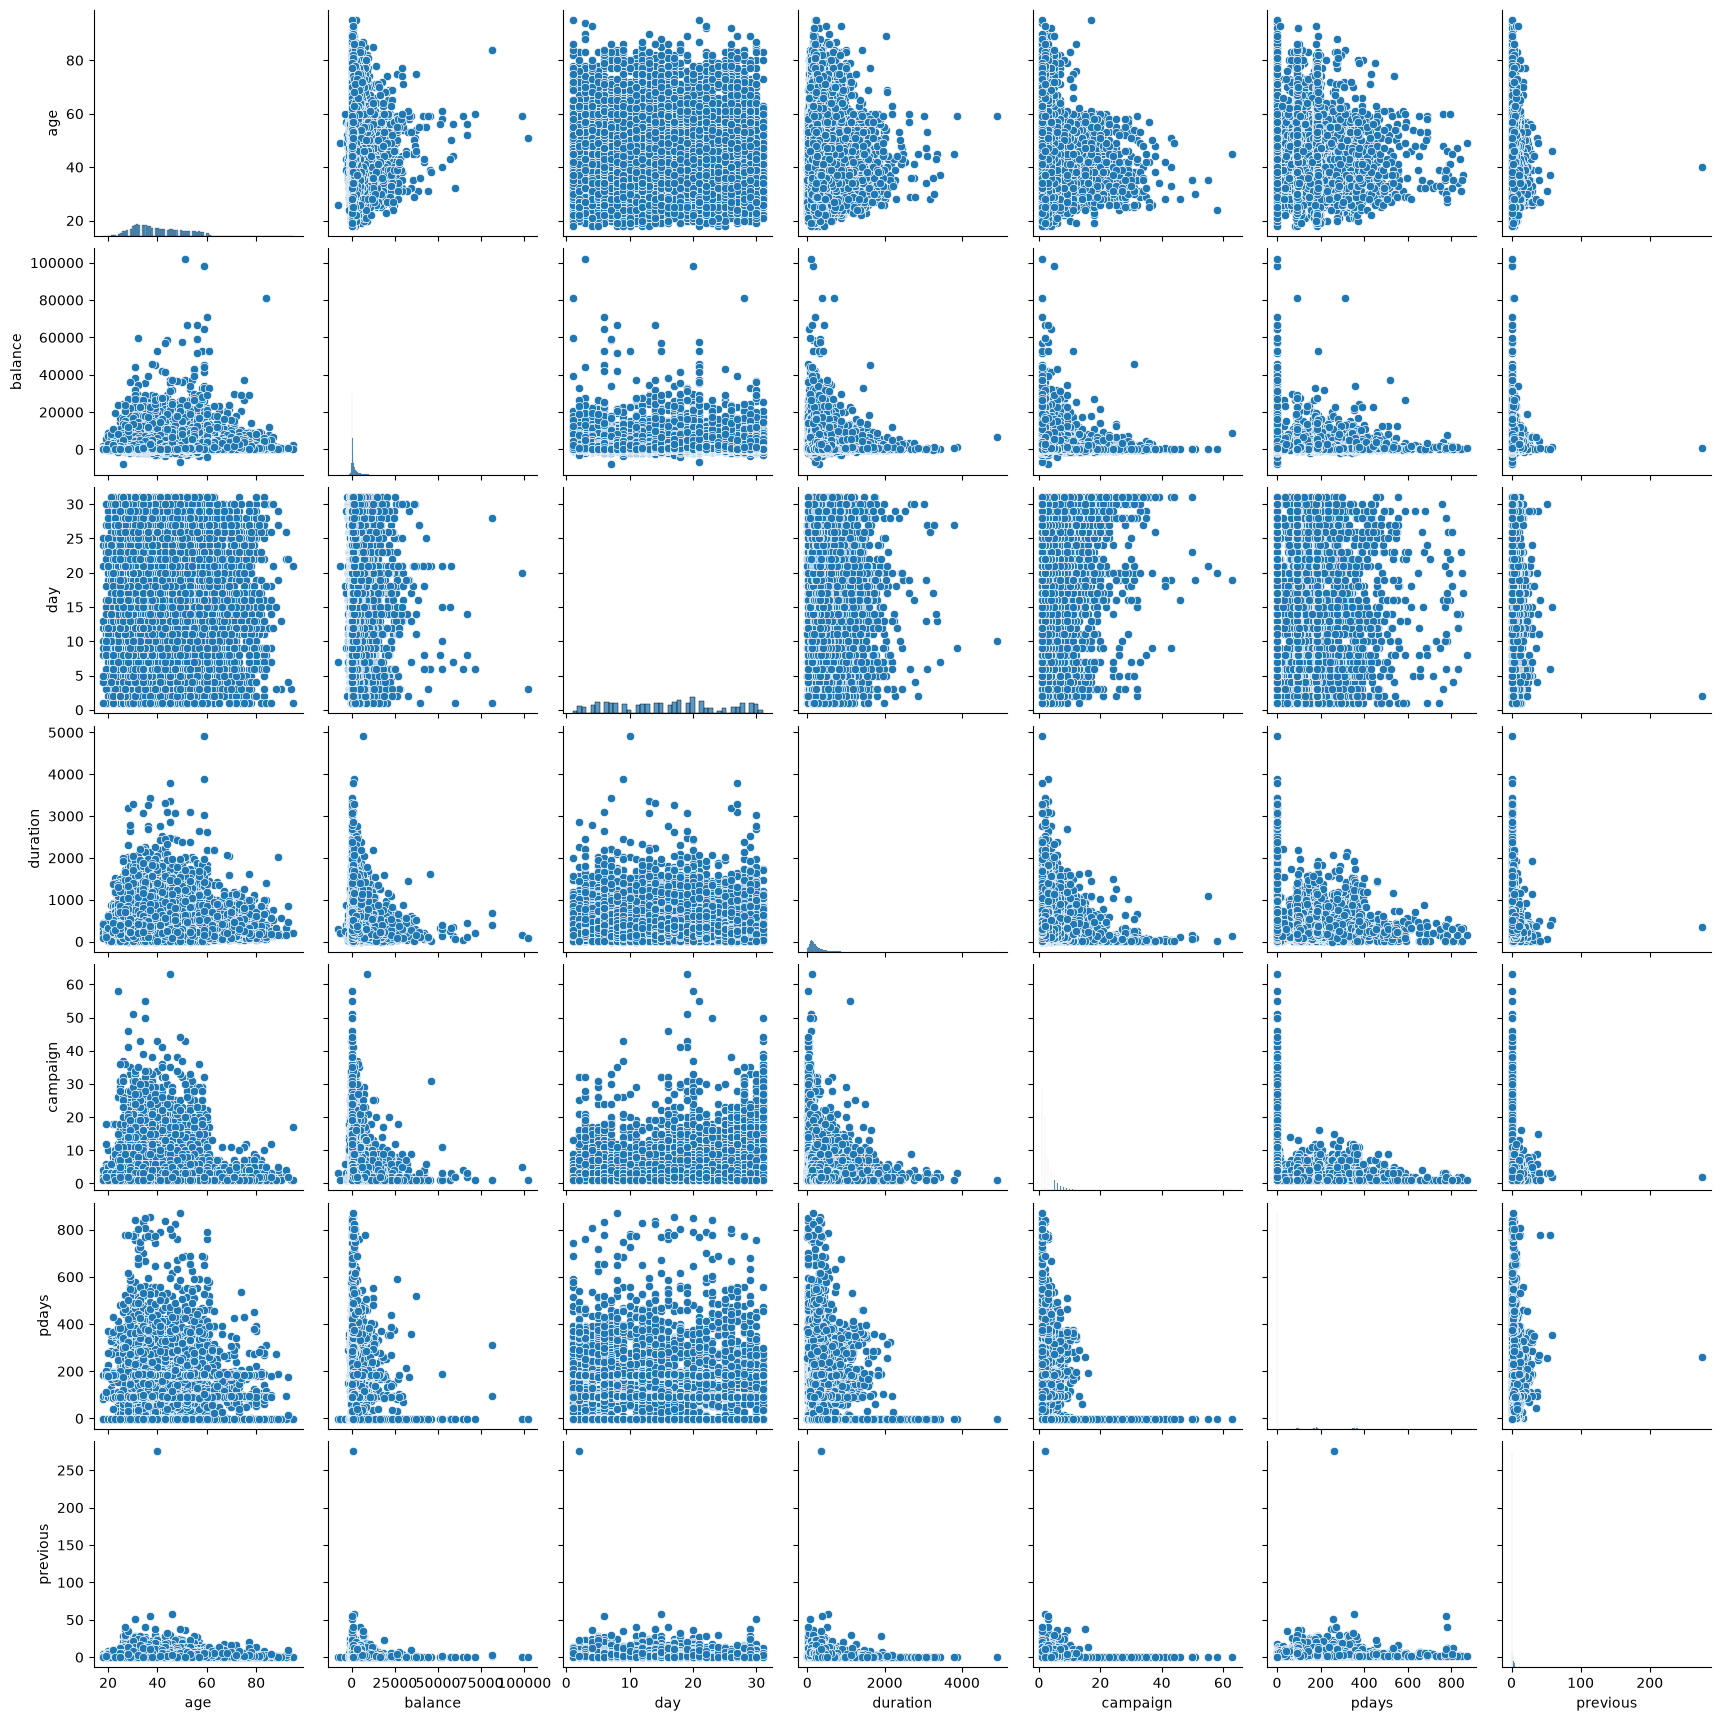

In [11]:
sns.pairplot(data=df,diag_kind="hist")
plt.show()

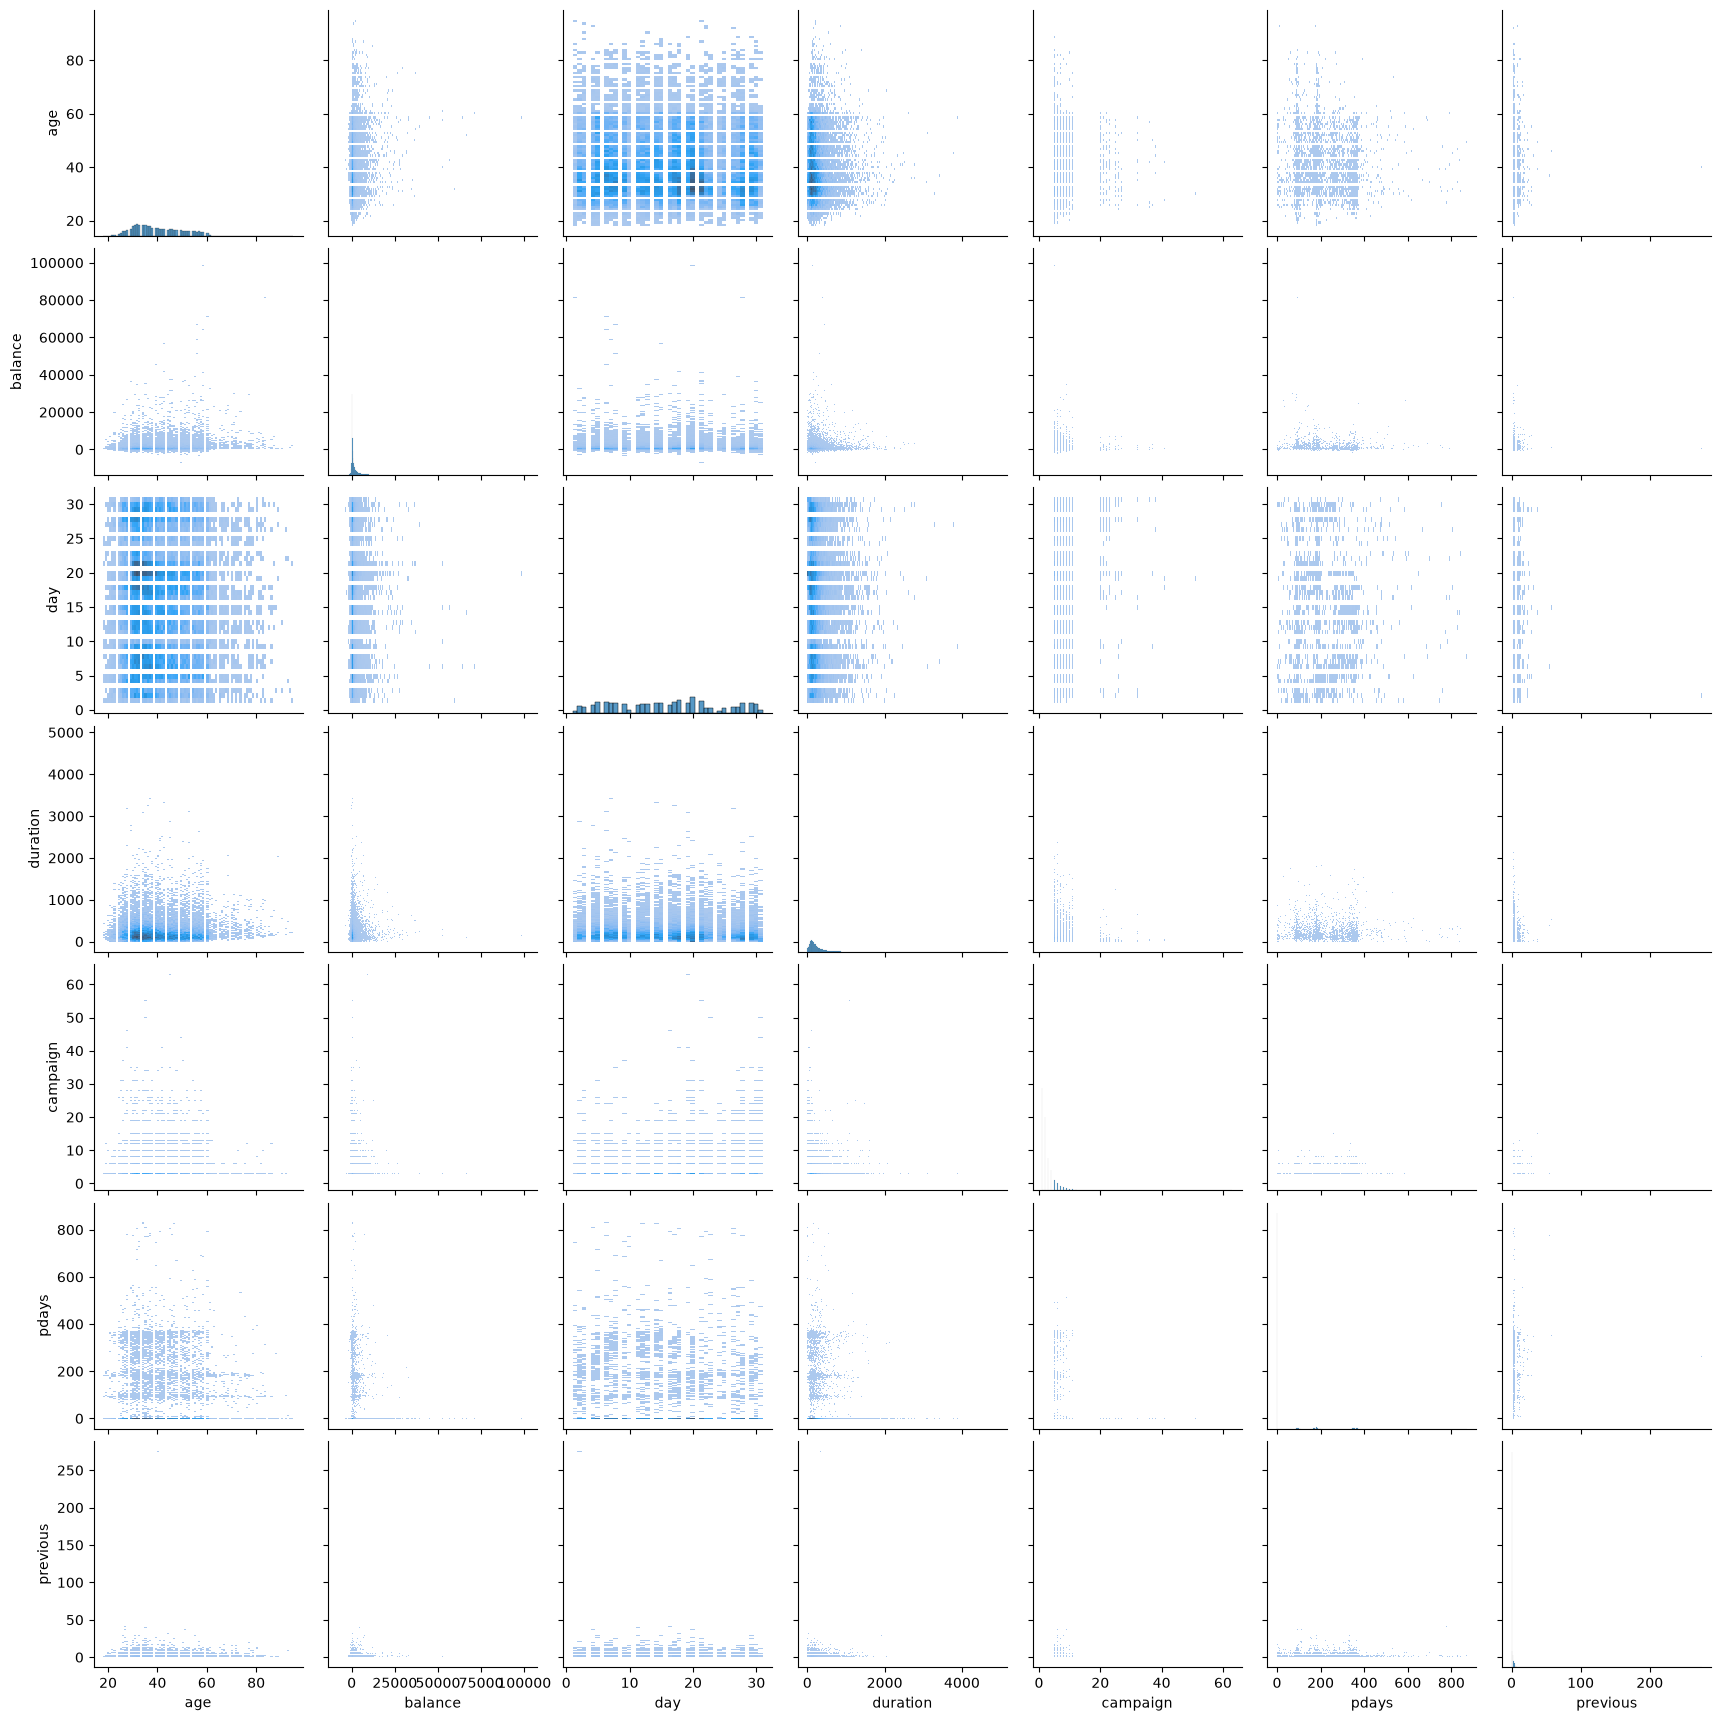

In [9]:
sns.pairplot(data=df,kind="hist")
plt.show()

In [14]:
df["marital"] = df["marital"].map(
    {
        "married":1,
        "single":0,
        "divorced":0
    }
)

In [15]:
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management        1   tertiary      no     2143     yes   no   
1   44    technician        0  secondary      no       29     yes   no   
2   33  entrepreneur        1  secondary      no        2     yes  yes   
3   47   blue-collar        1    unknown      no     1506     yes   no   
4   33       unknown        0    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [16]:
x=df.drop(columns=["y"])
y=df["y"]
print(y)

0         no
1         no
2         no
3         no
4         no
        ... 
45206    yes
45207    yes
45208    yes
45209     no
45210     no
Name: y, Length: 45211, dtype: str


In [17]:
df.dtypes

age          int64
job            str
marital      int64
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

In [22]:
numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = df.select_dtypes(
    include=["object"]
).columns


print("Numerical:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numerical:
Index(['age', 'marital', 'balance', 'day', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='str')

Categorical:
Index(['job', 'education', 'default', 'housing', 'loan', 'contact', 'month',
       'poutcome', 'y'],
      dtype='str')


C:\Users\INDIA\AppData\Local\Temp\ipykernel_20016\2751670636.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


In [23]:
categorical_features = df.drop(columns=["y"]).select_dtypes(include=["object"]).columns

C:\Users\INDIA\AppData\Local\Temp\ipykernel_20016\3832812412.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.drop(columns=["y"]).select_dtypes(include=["object"]).columns


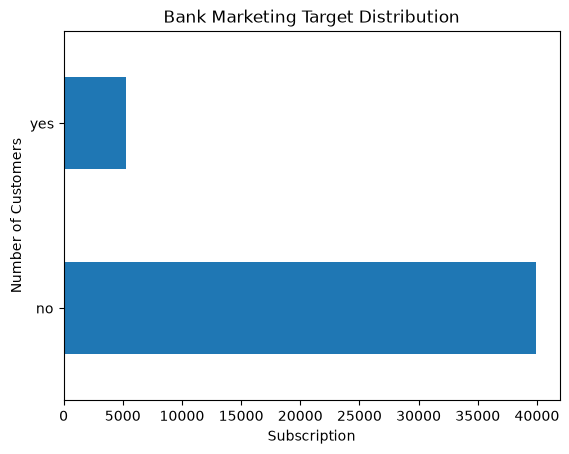

In [25]:
df["y"].value_counts().plot(kind="barh")
plt.title("Bank Marketing Target Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

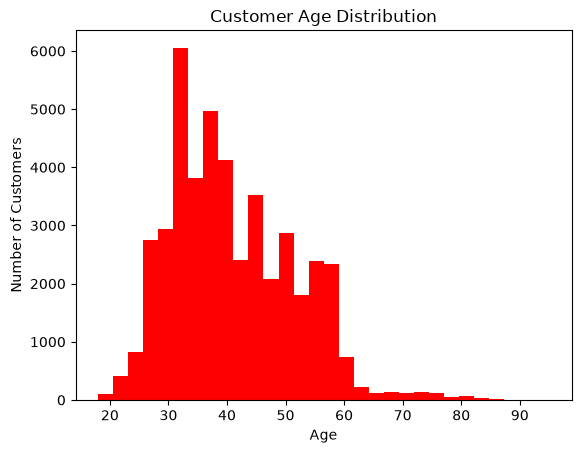

In [29]:
plt.hist(df["age"],bins=30,color="r")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

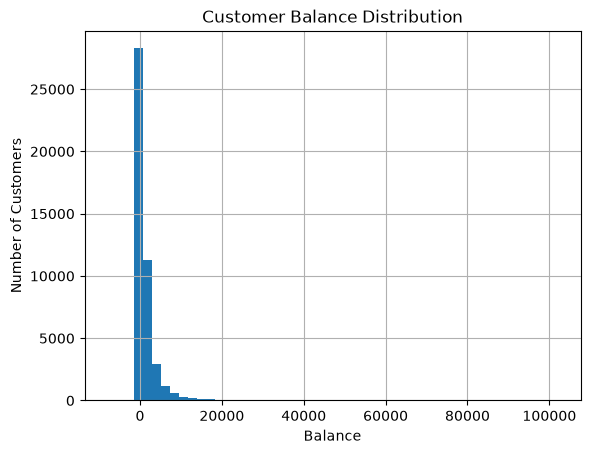

In [30]:
df["balance"].hist(bins=50)

plt.title("Customer Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")

plt.show()

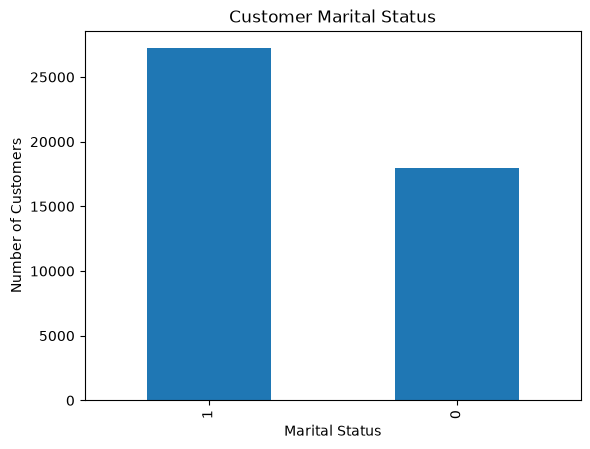

In [31]:
df["marital"].value_counts().plot(kind="bar")

plt.title("Customer Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.show()

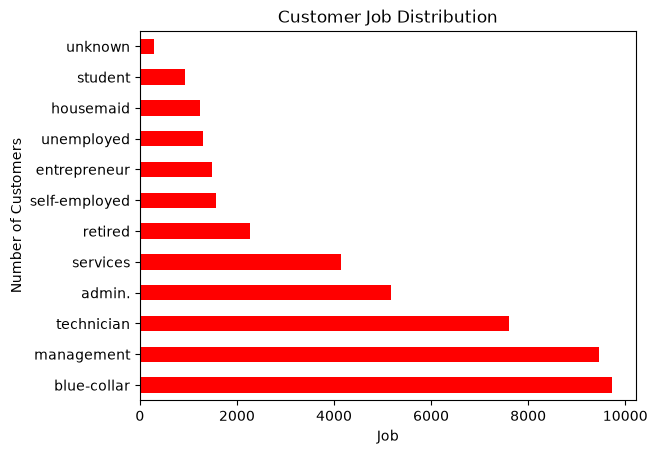

In [35]:
df["job"].value_counts().plot(kind="barh",color="red")

plt.title("Customer Job Distribution")
plt.xlabel("Job")
plt.ylabel("Number of Customers")

plt.show()

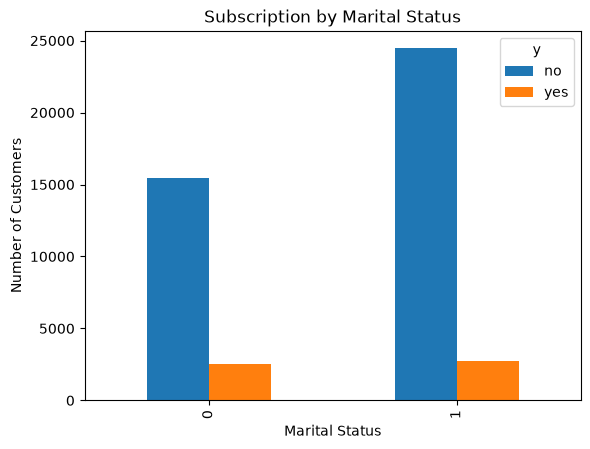

In [36]:
pd.crosstab(
    df["marital"],
    df["y"]
).plot(kind="bar")

plt.title("Subscription by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.show()

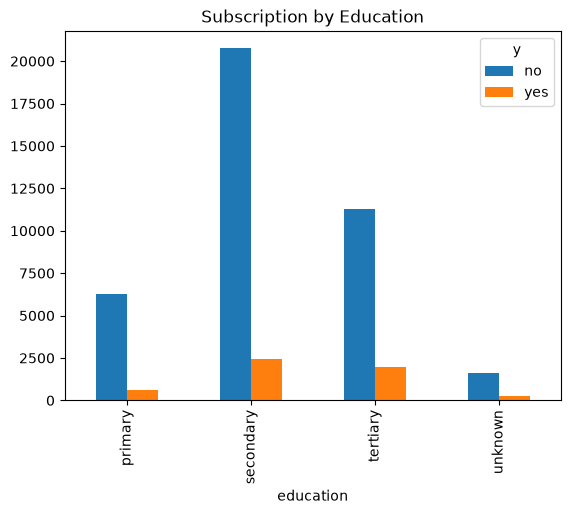

In [37]:
pd.crosstab(
    df["education"],
    df["y"]
).plot(kind="bar")

plt.title("Subscription by Education")
plt.show()

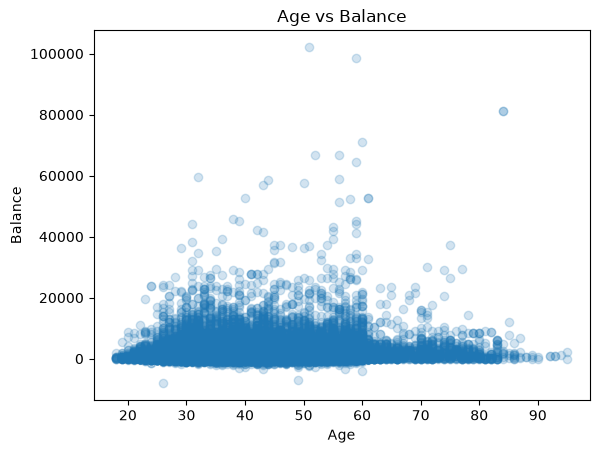

In [41]:
plt.scatter(
    df["age"],
    df["balance"],
    alpha=0.2
)

plt.xlabel("Age")
plt.ylabel("Balance")
plt.title("Age vs Balance")

plt.show()

In [42]:
# 5. Missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [45]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [46]:
print(
    df["y"].value_counts(normalize=True) * 100
)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


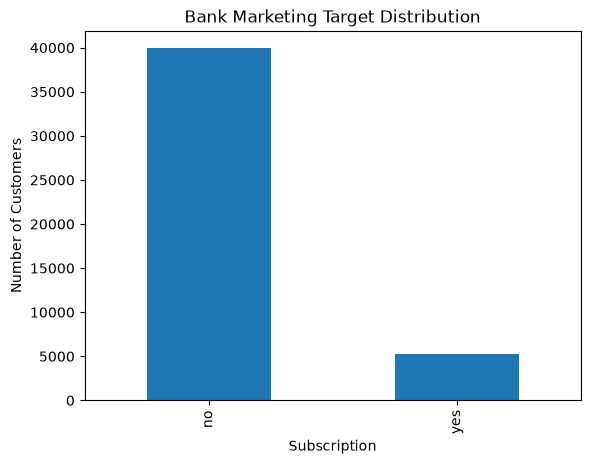

In [47]:
df["y"].value_counts().plot(
    kind="bar"
)

plt.title("Bank Marketing Target Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

In [49]:
correlation = df[numeric_features].corr()
print(correlation)

               age   marital   balance       day  duration  campaign  \
age       1.000000  0.286257  0.097783 -0.009120 -0.004648  0.004760   
marital   0.286257  1.000000  0.025708  0.007102 -0.022683  0.031371   
balance   0.097783  0.025708  1.000000  0.004503  0.021560 -0.014578   
day      -0.009120  0.007102  0.004503  1.000000 -0.030206  0.162490   
duration -0.004648 -0.022683  0.021560 -0.030206  1.000000 -0.084570   
campaign  0.004760  0.031371 -0.014578  0.162490 -0.084570  1.000000   
pdays    -0.023758 -0.027600  0.003435 -0.093044 -0.001565 -0.088628   
previous  0.001288 -0.012691  0.016674 -0.051710  0.001203 -0.032855   

             pdays  previous  
age      -0.023758  0.001288  
marital  -0.027600 -0.012691  
balance   0.003435  0.016674  
day      -0.093044 -0.051710  
duration -0.001565  0.001203  
campaign -0.088628 -0.032855  
pdays     1.000000  0.454820  
previous  0.454820  1.000000  


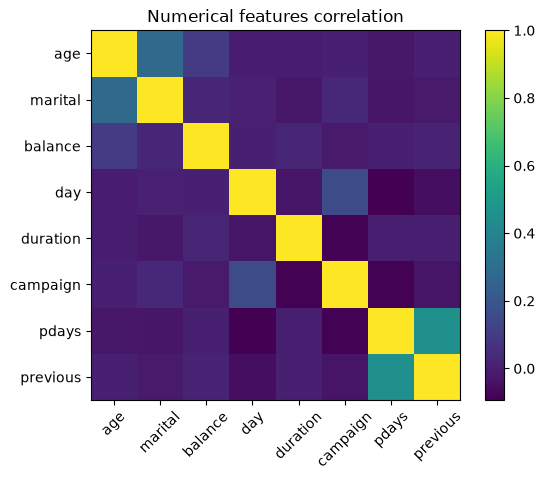

In [50]:
plt.imshow(correlation)
plt.colorbar()
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Numerical features correlation")
plt.show()

In [51]:
features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "day",
    "month",
    "campaign",
    "pdays",
    "previous",
    "poutcome"
]

x=df[features]
y=df["y"]

print(x.shape)
print(y.shape)

(45211, 15)
(45211,)


In [52]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (36168, 15)
Testing data: (9043, 15)


In [54]:
numeric_features = x.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = x.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'marital', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


C:\Users\INDIA\AppData\Local\Temp\ipykernel_20016\2649434205.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x.select_dtypes(


In [55]:
numeric_pipeline = Pipeline(
    [
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
    ]
)

In [56]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

print(categorical_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


In [57]:
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

In [58]:
knn_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
])

In [60]:
knn_model.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remainin

In [61]:
y_pred = knn_model.predict(x_test)

In [62]:
print(y_pred[:20])

['no' 'no' 'no' 'no' 'no' 'no' 'no' 'yes' 'no' 'no' 'no' 'no' 'no' 'no'
 'no' 'no' 'no' 'no' 'no' 'no']


In [63]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8876479044564857


In [65]:
precision = precision_score(
    y_test,
    y_pred,
    pos_label="yes"
)

print("Precision:", precision)

Precision: 0.5564516129032258


In [66]:
recall = recall_score(
    y_test,
    y_pred,
    pos_label="yes"
)

print("Recall:", recall)

Recall: 0.1956521739130435


In [67]:
f1 = f1_score(
    y_test,
    y_pred,
    pos_label="yes"
)

print("F1 Score:", f1)

F1 Score: 0.2895104895104895


In [68]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

          no       0.90      0.98      0.94      7985
         yes       0.56      0.20      0.29      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.59      0.61      9043
weighted avg       0.86      0.89      0.86      9043

